In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# California Housing
df = pd.read_csv('/content/sample_data/california_housing_test.csv')
df_train = pd.read_csv('/content/sample_data/california_housing_train.csv')
print(df.head())
print(df_train.head())
print(df.shape)
print(df_train.shape)
print(df.info())
print(df_train.info())
print(df.describe())
print(df_train.describe())
print(df.isnull().sum())
print(df_train.isnull().sum())
print(df.columns)
print(df_train.columns)
print(df.dtypes)
print(df_train.dtypes)
# MNIST
df_mnist_test = pd.read_csv('/content/sample_data/mnist_test.csv')
df_mnist_train = pd.read_csv('/content/sample_data/mnist_train_small.csv')
print(df_mnist_train.head())
print(df_mnist_test.head())
print(df_mnist_train.shape)
print(df_mnist_test.shape)
print(df_mnist_train.info())
print(df_mnist_test.info())
print(df_mnist_train.describe())
print(df_mnist_test.describe())
print(df_mnist_train.isnull().sum())
print(df_mnist_test.isnull().sum())
print(df_mnist_train.columns)
print(df_mnist_test.columns)
print(df_mnist_train.dtypes)
print(df_mnist_test.dtypes)
print(df_mnist_train.nunique())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.05     37.37                27.0       3885.0           661.0   
1    -118.30     34.26                43.0       1510.0           310.0   
2    -117.81     33.78                27.0       3589.0           507.0   
3    -118.36     33.82                28.0         67.0            15.0   
4    -119.67     36.33                19.0       1241.0           244.0   

   population  households  median_income  median_house_value  
0      1537.0       606.0         6.6085            344700.0  
1       809.0       277.0         3.5990            176500.0  
2      1484.0       495.0         5.7934            270500.0  
3        49.0        11.0         6.1359            330000.0  
4       850.0       237.0         2.9375             81700.0  
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -114.31     34.19                15.0       5612.0          1283.0   
1    -114.47     34.4

In [ ]:
# Target variable distribution — always start here
df['median_house_value'].value_counts()
df['median_house_value'].value_counts(normalize=True) * 100  # as percentages

,proportion
median_house_value,
500001.0,4.166667
137500.0,0.766667
162500.0,0.700000
225000.0,0.566667
350000.0,0.466667
...,...
376200.0,0.033333
89100.0,0.033333
166900.0,0.033333


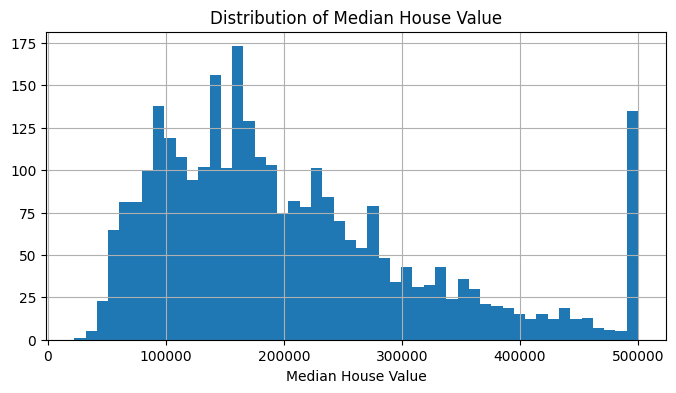

In [ ]:
# Target variable distribution
df['median_house_value'].hist(bins=50, figsize=(8,4))
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value')
plt.show()

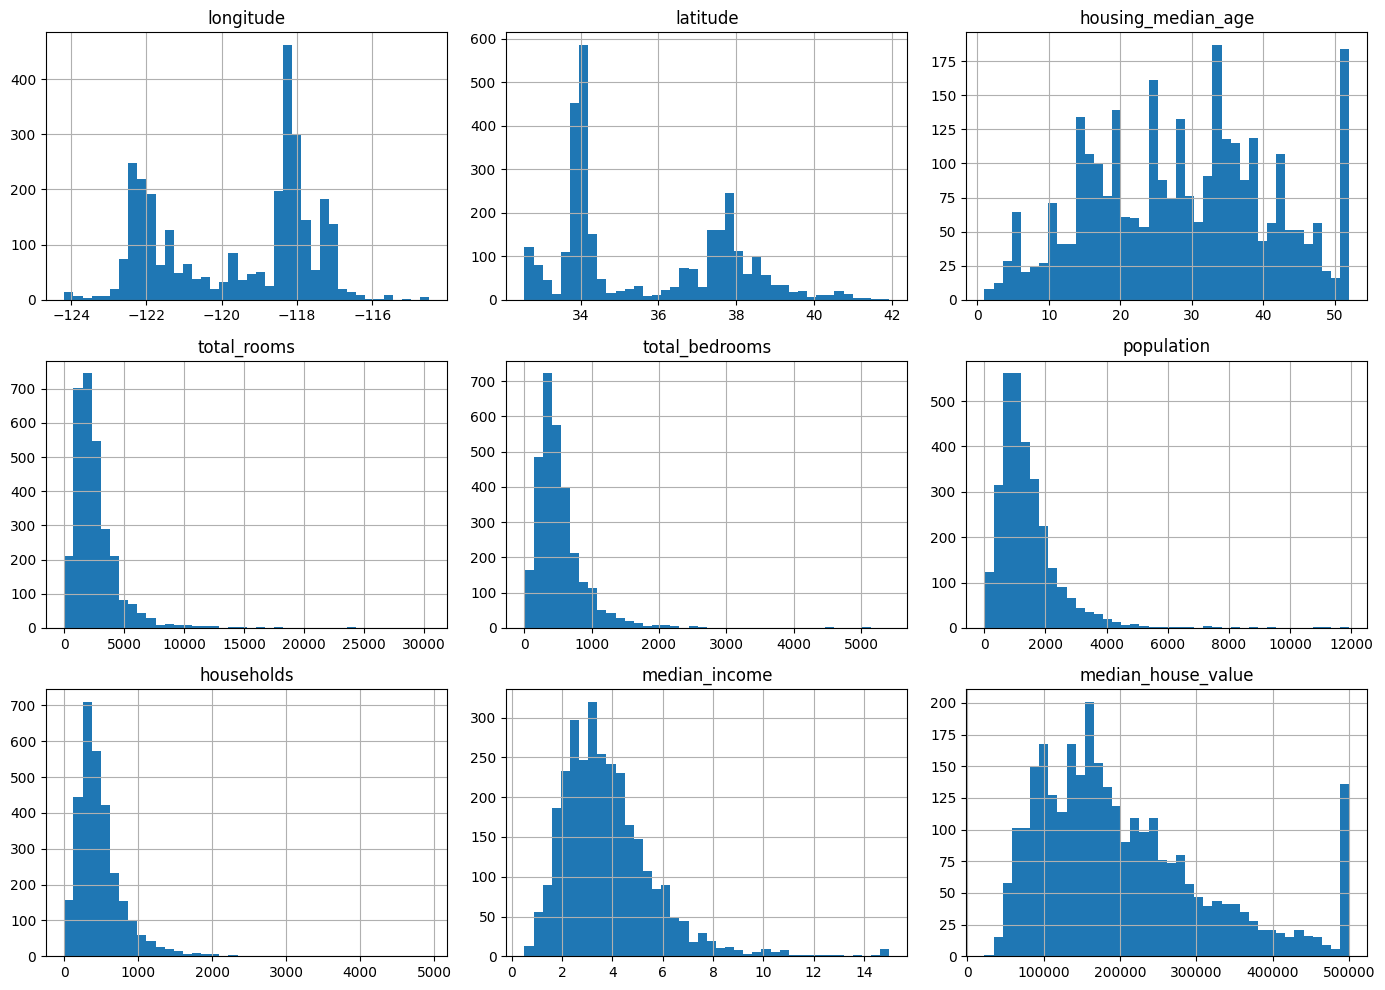

In [ ]:
# Univariate — all numerical columns
df.hist(figsize=(14,10), bins=40)
plt.tight_layout()
plt.show()

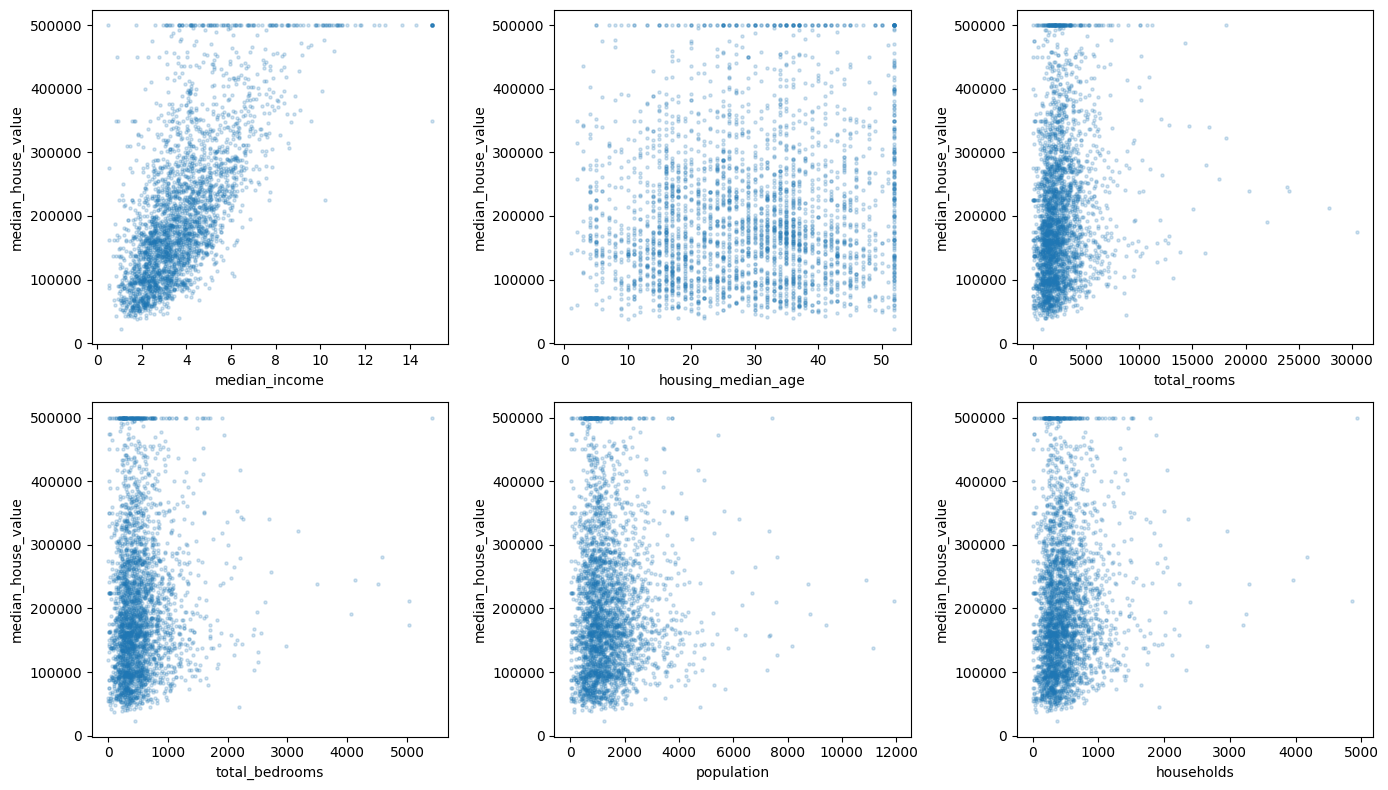

In [ ]:
# Bivariate — features vs target
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
features = ['median_income', 'housing_median_age', 'total_rooms',
            'total_bedrooms', 'population', 'households']

for ax, feat in zip(axes.flatten(), features):
    ax.scatter(df[feat], df['median_house_value'], alpha=0.2, s=5)
    ax.set_xlabel(feat)
    ax.set_ylabel('median_house_value')
plt.tight_layout()
plt.show()

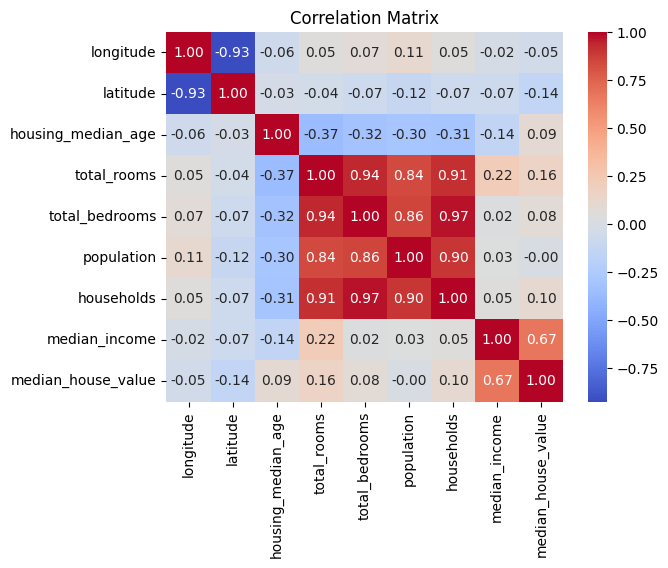

In [ ]:
# Correlation heatmap
sns.heatmap(df.select_dtypes('number').corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

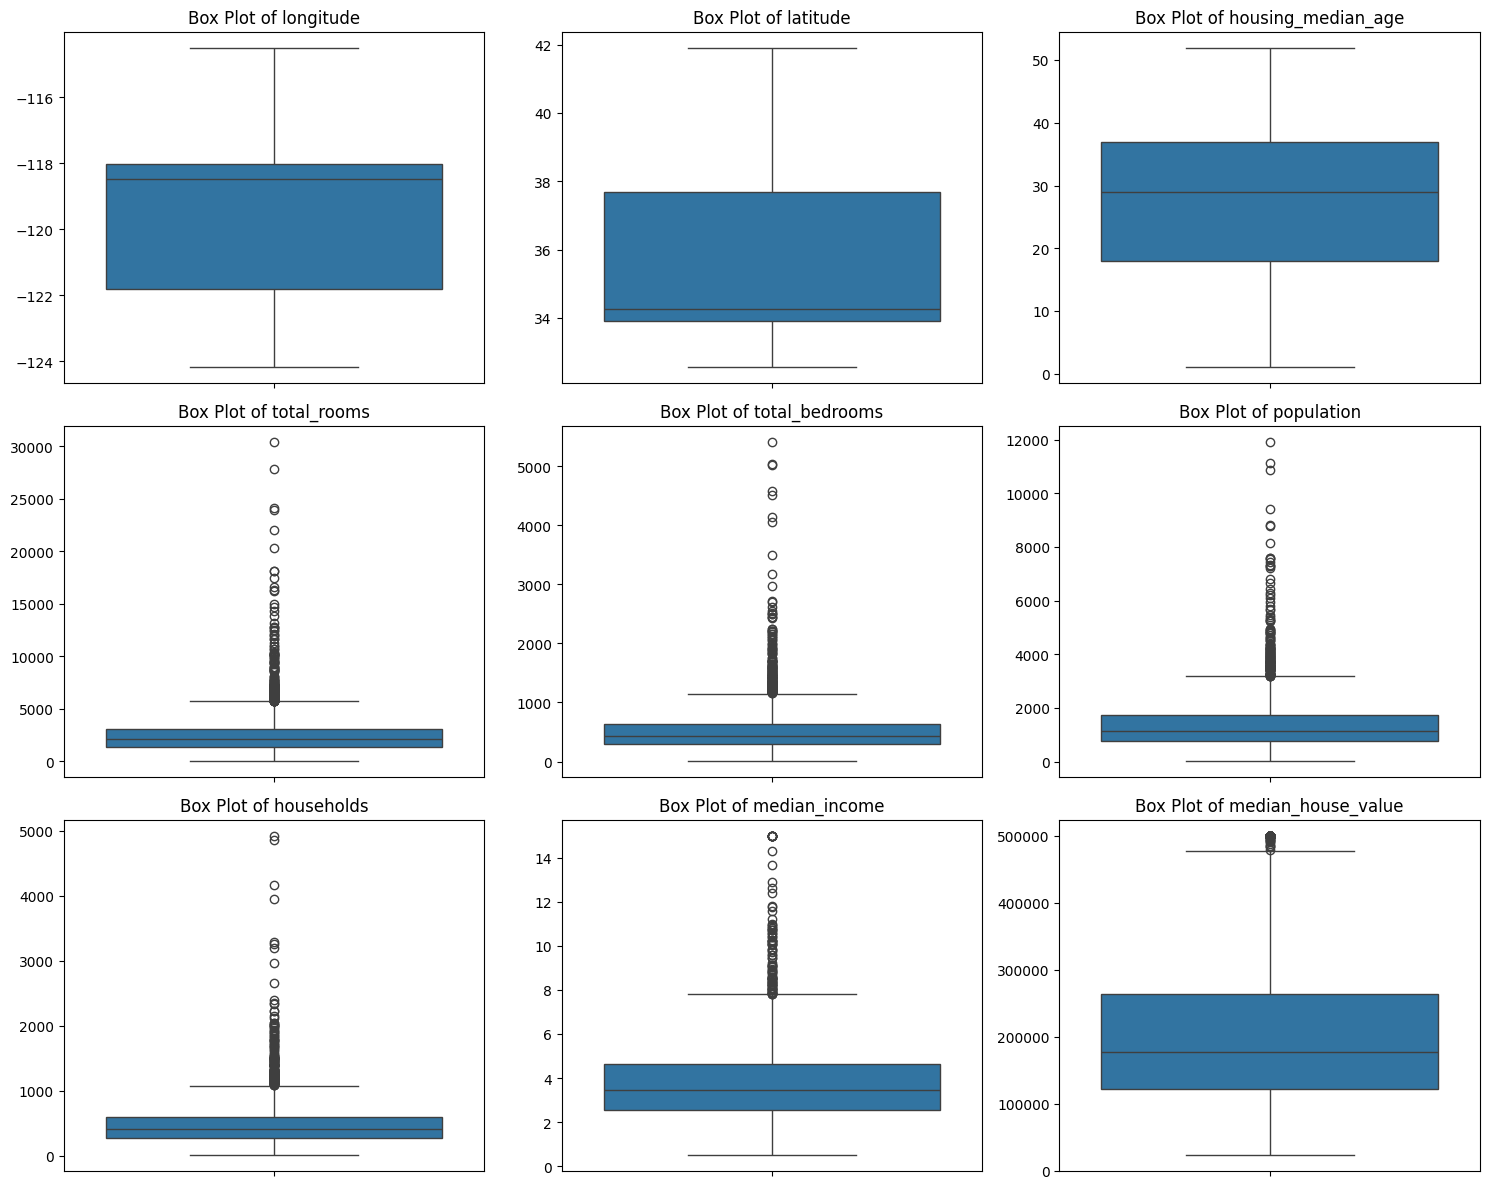

In [ ]:
# Generate box plots for numerical features in df
numerical_cols = df.select_dtypes(include=np.number).columns

# Determine the number of rows and columns for subplots
num_cols = 3  # You can adjust this for desired layout
num_rows = (len(numerical_cols) + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 5, num_rows * 4))
axes = axes.flatten() # Flatten the array of axes for easy iteration

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Box Plot of {col}')
    axes[i].set_ylabel('') # Remove y-label as title is sufficient

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

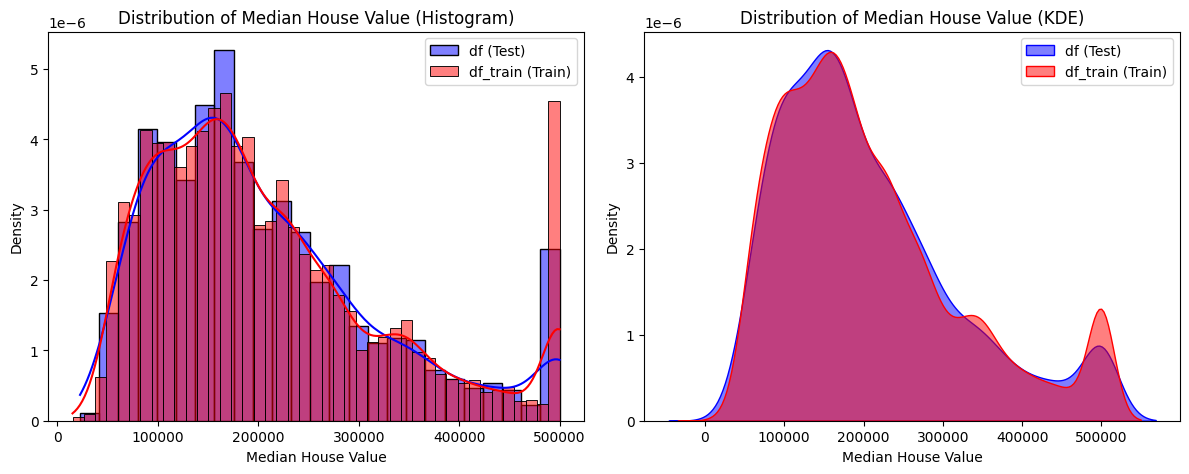

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(df['median_house_value'], color='blue', label='df (Test)', kde=True, stat='density', alpha=0.5)
sns.histplot(df_train['median_house_value'], color='red', label='df_train (Train)', kde=True, stat='density', alpha=0.5)
plt.title('Distribution of Median House Value (Histogram)')
plt.xlabel('Median House Value')
plt.ylabel('Density')
plt.legend()

# KDE Plot
plt.subplot(1, 2, 2)
sns.kdeplot(df['median_house_value'], color='blue', label='df (Test)', fill=True, alpha=0.5)
sns.kdeplot(df_train['median_house_value'], color='red', label='df_train (Train)', fill=True, alpha=0.5)
plt.title('Distribution of Median House Value (KDE)')
plt.xlabel('Median House Value')
plt.ylabel('Density')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# @title step_artifacts
num_fig = "1" # @param {type:"string"}
step = 'DataExploration'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# Uncomment the following line if you have an `upload_plt_to_gcs` function defined
# upload_plt_to_gcs(num_fig, step, plt.gcf())

/tmp/ipykernel_724/2733431678.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['log_house_value'] = np.log1p(df['median_house_value'])


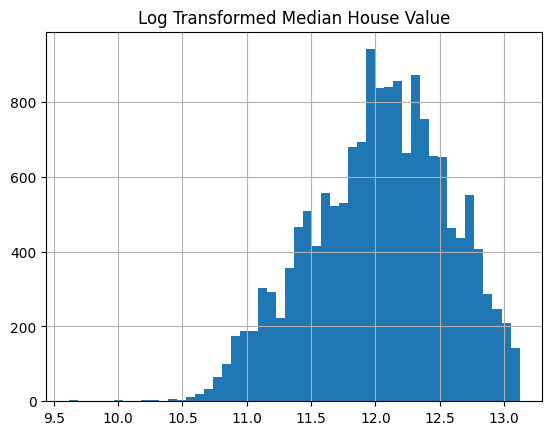

In [ ]:
# 1. Remove the capped values
df_train = df_train[df_train['median_house_value'] < 500000]
df = df[df['median_house_value'] < 500000]

# 2. Log transform the target (fixes the right skew)
import numpy as np
df_train['log_house_value'] = np.log1p(df_train['median_house_value'])
df['log_house_value'] = np.log1p(df['median_house_value'])

# 3. Check the distribution again — should look more normal now
df_train['log_house_value'].hist(bins=50)
plt.title('Log Transformed Median House Value')
plt.show()

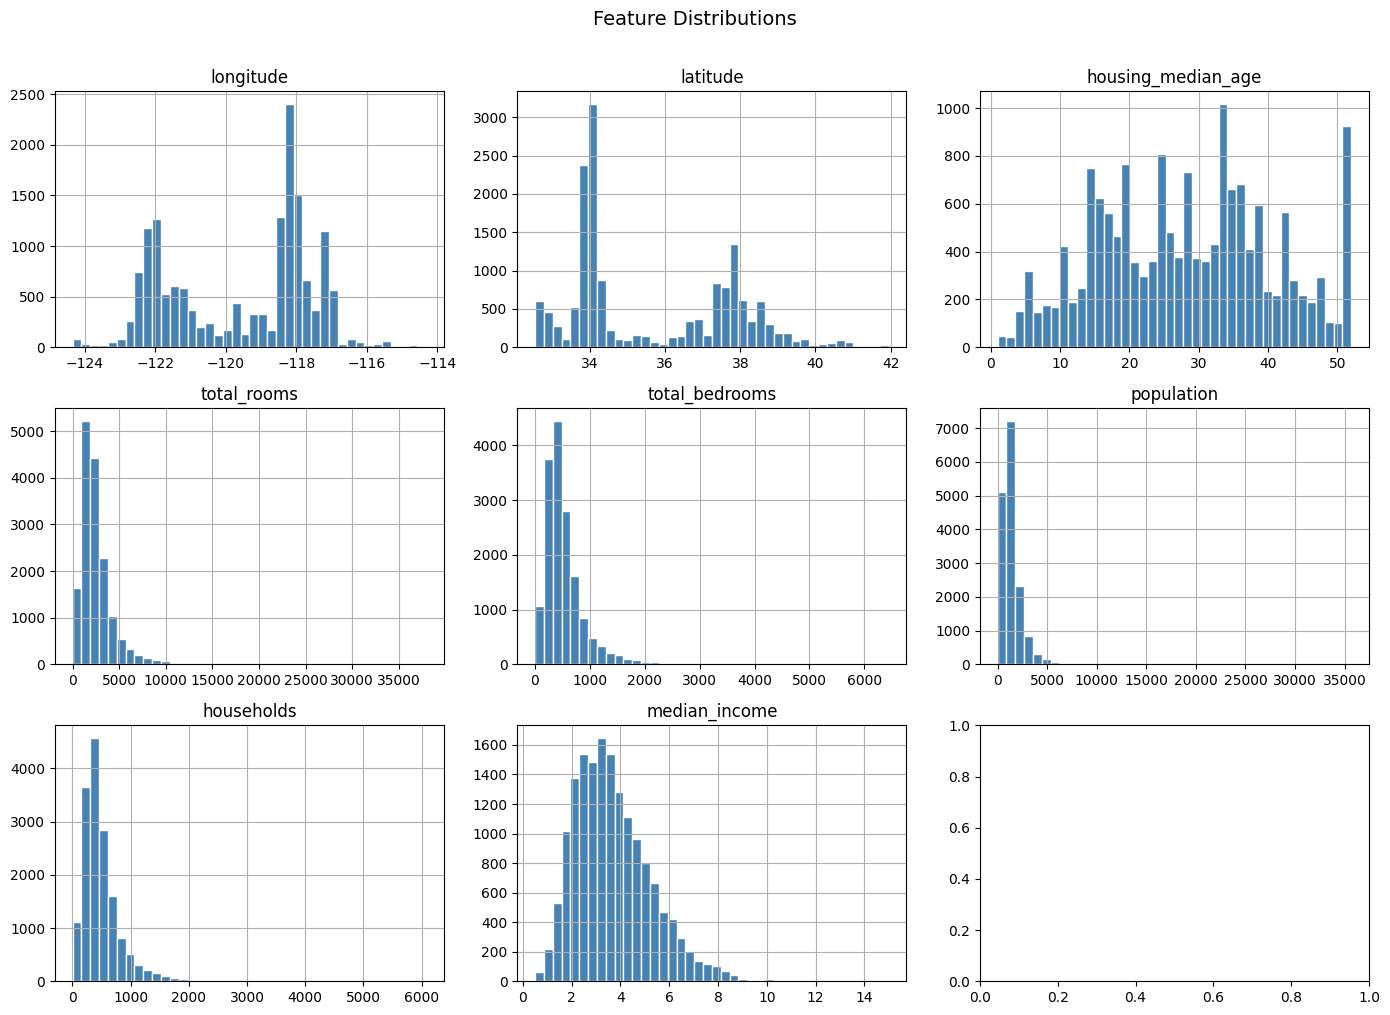

In [ ]:
# All features at once
features = ['longitude', 'latitude', 'housing_median_age',
            'total_rooms', 'total_bedrooms', 'population',
            'households', 'median_income']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))

for ax, feat in zip(axes.flatten(), features):
    df_train[feat].hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(feat)
    ax.set_xlabel('')

plt.suptitle('Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# 1. Remove capped values
# Only apply capping if 'median_house_value' column exists
if 'median_house_value' in df_train.columns:
    df_train = df_train[df_train['median_house_value'] < 500000]

# Filter housing_median_age if it exists
if 'housing_median_age' in df_train.columns:
    df_train = df_train[df_train['housing_median_age'] < 52]

# 2. Log transform target
# Only create 'log_house_value' if 'median_house_value' exists and 'log_house_value' does not
if 'median_house_value' in df_train.columns and 'log_house_value' not in df_train.columns:
    df_train['log_house_value'] = np.log1p(df_train['median_house_value'])

# 3. Engineer ratio features
# Define base columns required for ratios and the ratio columns themselves
base_cols_for_ratios = {
    'rooms_per_household': ('total_rooms', 'households'),
    'bedrooms_per_room': ('total_bedrooms', 'total_rooms'),
    'population_per_household': ('population', 'households')
}

for ratio_col, (numerator_col, denominator_col) in base_cols_for_ratios.items():
    if ratio_col not in df_train.columns and numerator_col in df_train.columns and denominator_col in df_train.columns:
        df_train[ratio_col] = df_train[numerator_col] / df_train[denominator_col]
    elif ratio_col not in df_train.columns:
        # If ratio column is missing but base columns are also missing, it implies they were dropped.
        # This implies previous successful run or state change. Skip creating this ratio.
        pass # Optionally add a print(f"Warning: Skipping creation of {ratio_col} as base columns are missing.")

# 4. Drop raw totals (replaced by ratios)
columns_to_drop_raw = ['total_rooms', 'total_bedrooms', 'population']
for col in columns_to_drop_raw:
    if col in df_train.columns:
        df_train.drop(columns=[col], inplace=True)

# 5. Drop original target (using log version)
# Only drop 'median_house_value' if it exists and 'log_house_value' exists (meaning it was successfully created)
if 'median_house_value' in df_train.columns and 'log_house_value' in df_train.columns:
    df_train.drop(columns=['median_house_value'], inplace=True)

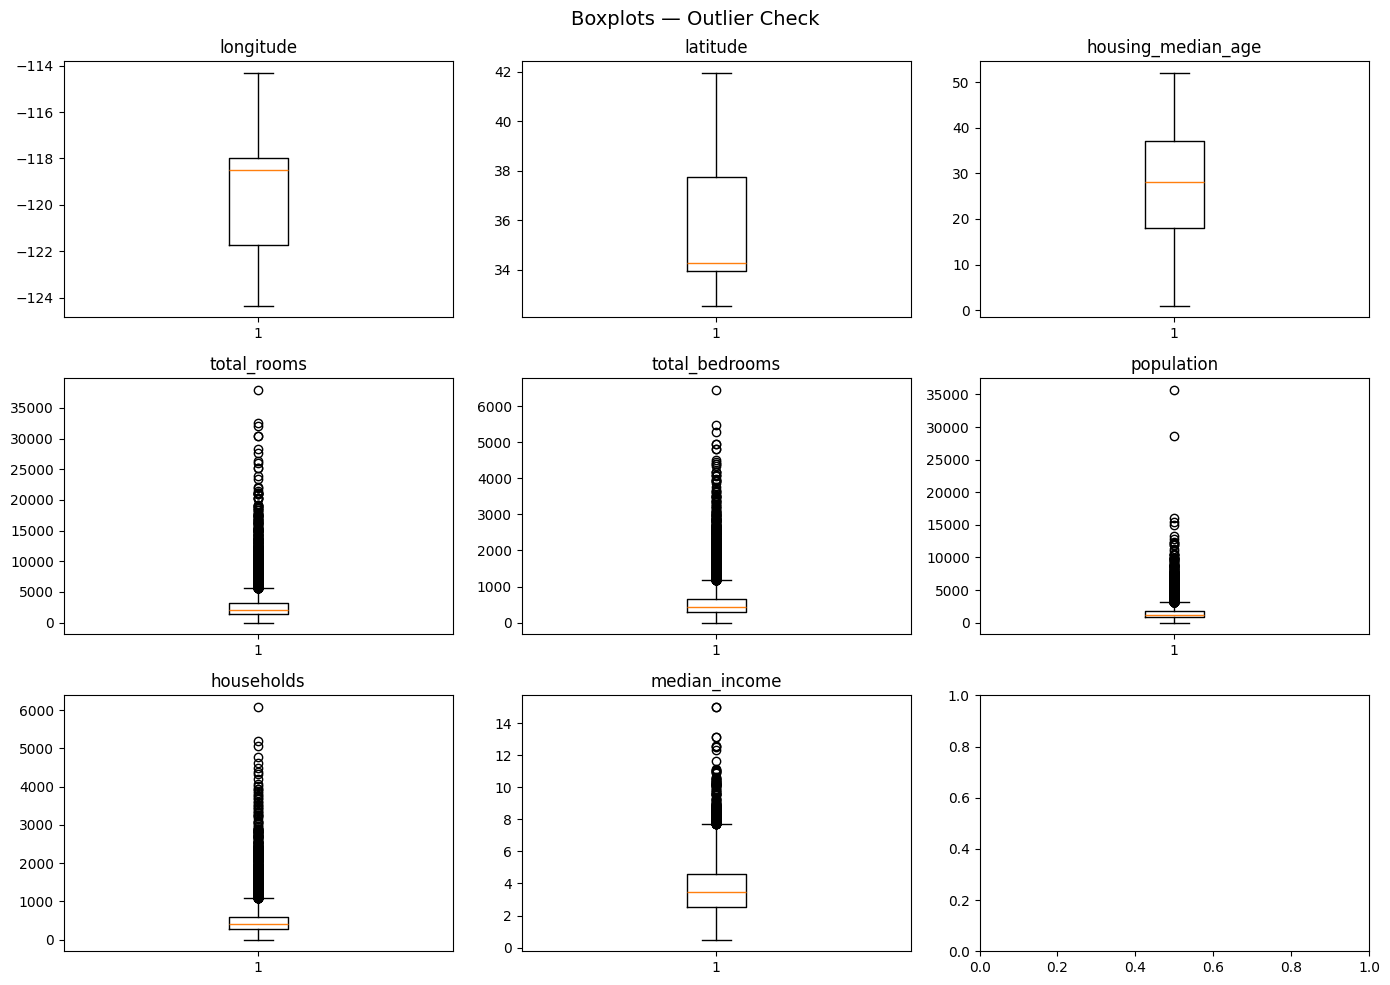

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))

for ax, feat in zip(axes.flatten(), features):
    ax.boxplot(df_train[feat].dropna(), vert=True)
    ax.set_title(feat)

plt.suptitle('Boxplots — Outlier Check', fontsize=14)
plt.tight_layout()
plt.show()

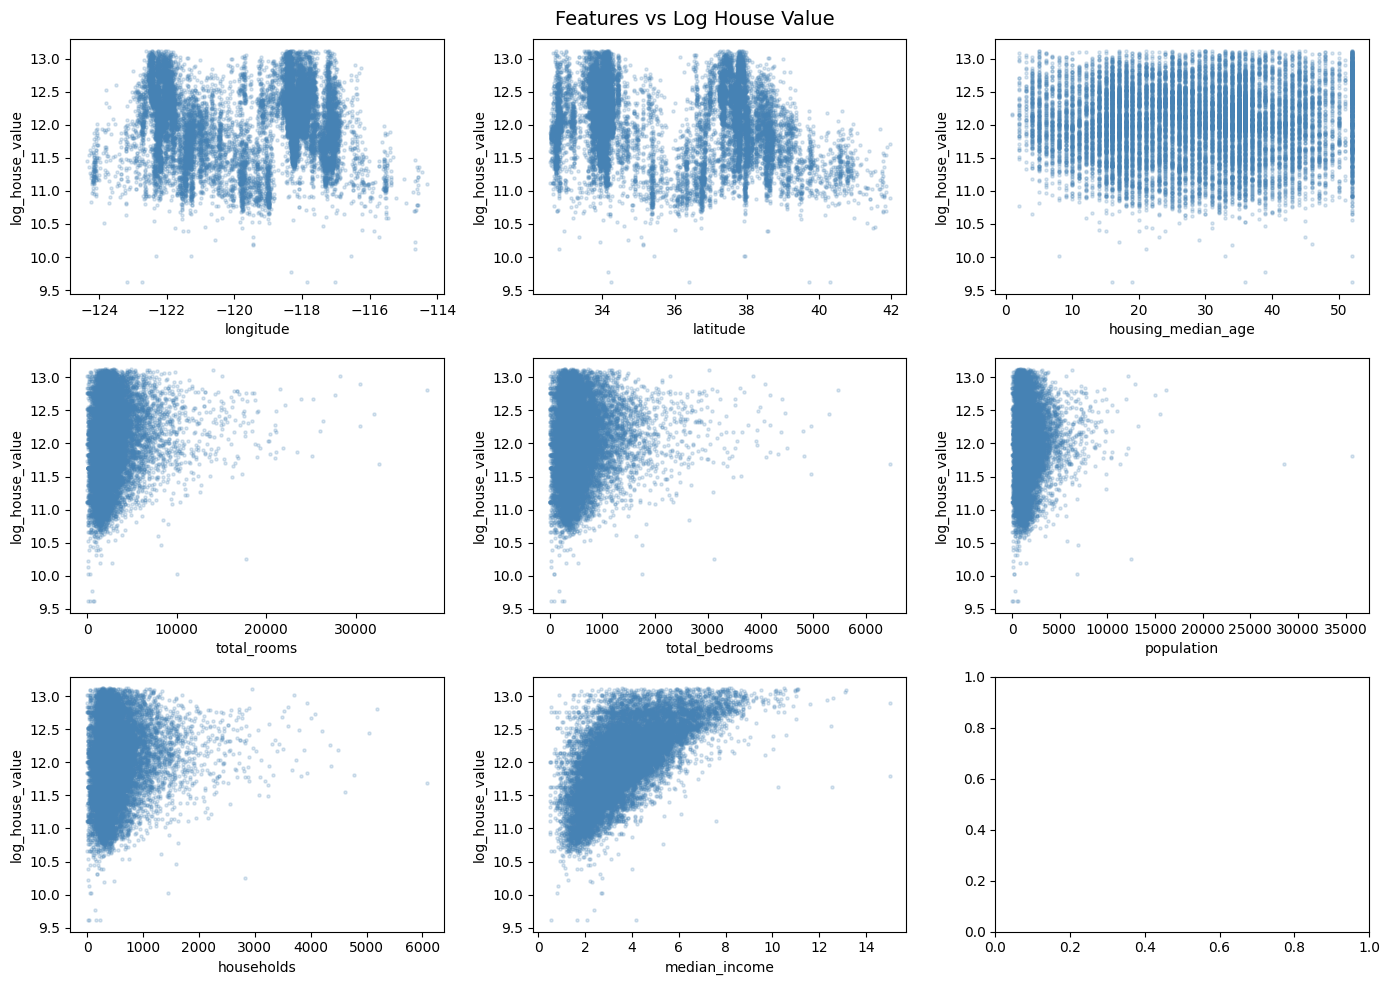

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))

for ax, feat in zip(axes.flatten(), features):
    ax.scatter(df_train[feat], df_train['log_house_value'],
               alpha=0.2, s=5, color='steelblue')
    ax.set_xlabel(feat)
    ax.set_ylabel('log_house_value')

plt.suptitle('Features vs Log House Value', fontsize=14)
plt.tight_layout()
plt.show()

log_house_value       1.000000
median_income         0.644880
total_rooms           0.157706
households            0.117234
total_bedrooms        0.095510
population            0.042655
housing_median_age    0.042558
longitude            -0.016708
latitude             -0.197520
Name: log_house_value, dtype: float64


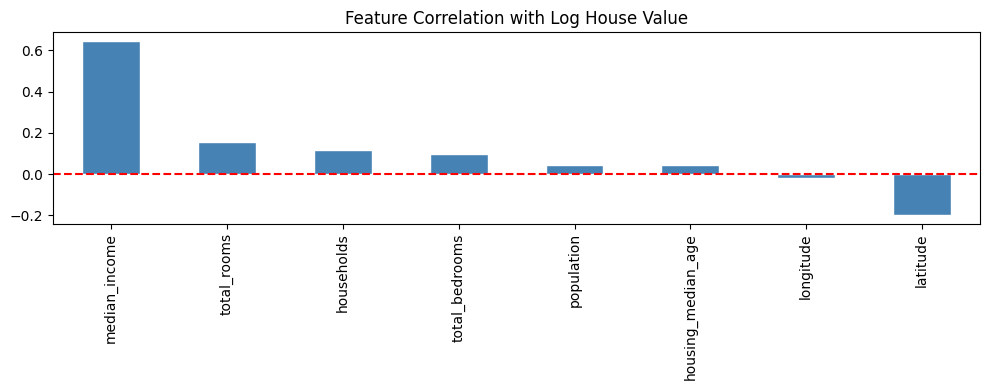

In [ ]:
corr = df_train[features + ['log_house_value']].corr()['log_house_value'].sort_values(ascending=False)
print(corr)

# Visual
corr.drop('log_house_value').plot(kind='bar', figsize=(10, 4),
                                   color='steelblue', edgecolor='white')
plt.title('Feature Correlation with Log House Value')
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

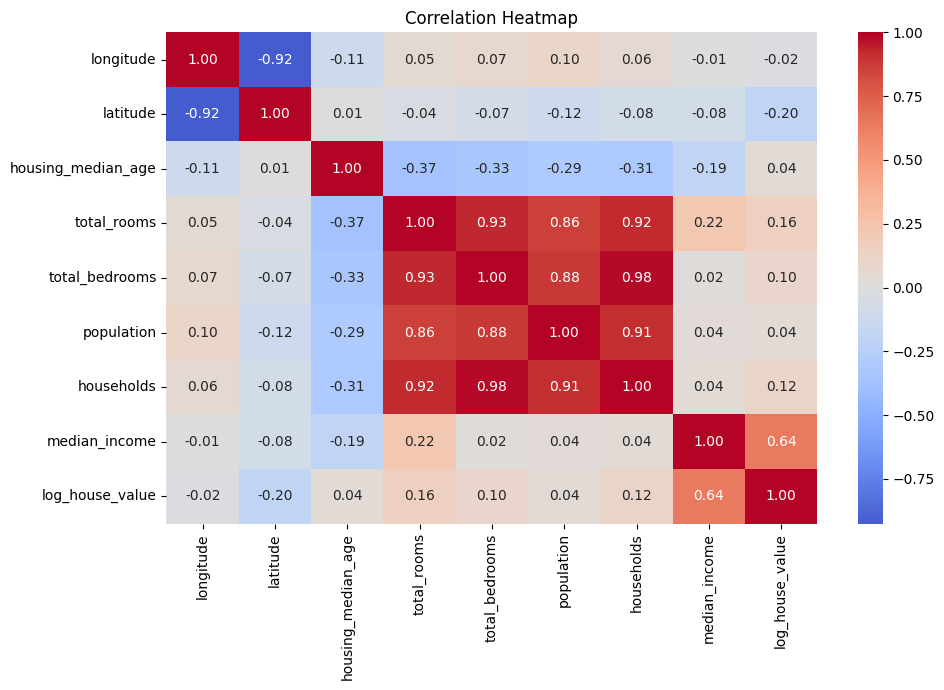

In [ ]:
plt.figure(figsize=(10, 7))
sns.heatmap(df_train[features + ['log_house_value']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

log_house_value             1.000000
median_income               0.659968
rooms_per_household         0.097859
longitude                   0.005426
housing_median_age         -0.002217
population_per_household   -0.028653
latitude                   -0.218992
bedrooms_per_room          -0.219609
Name: log_house_value, dtype: float64


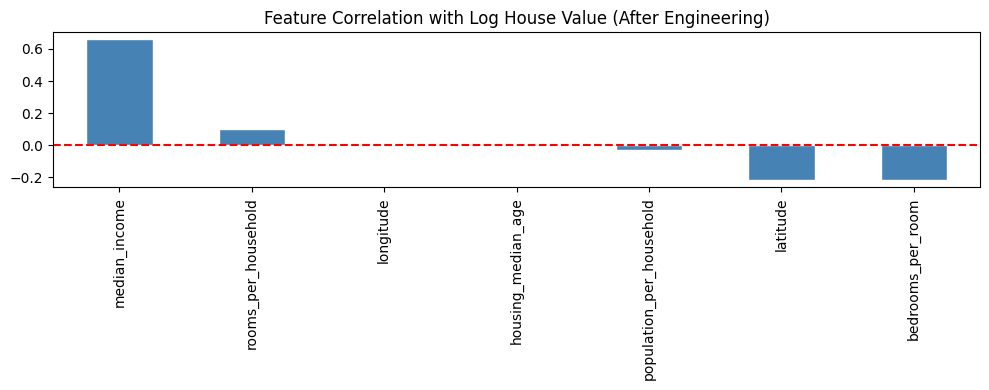

In [ ]:
# Re-check correlation with new features
# The ratio features (rooms_per_household, bedrooms_per_room, population_per_household)
# are assumed to have been engineered in a previous step (e.g., cell uTrnSiqgDUQR).
# Original 'total_rooms', 'total_bedrooms', 'population' columns are also assumed to be dropped.
new_features = ['median_income', 'housing_median_age', 'longitude', 'latitude',
                'rooms_per_household', 'bedrooms_per_room', 'population_per_household']

corr = df_train[new_features + ['log_house_value']].corr()['log_house_value'].sort_values(ascending=False)
print(corr)

# Visual
corr.drop('log_house_value').plot(kind='bar', figsize=(10, 4),
                                   color='steelblue', edgecolor='white')
plt.title('Feature Correlation with Log House Value (After Engineering)')
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import numpy as np

# --- Apply the same feature engineering steps to df (test set) as were applied to df_train ---

# 1. Remove capped values from df
if 'median_house_value' in df.columns:
    df = df[df['median_house_value'] < 500000]
if 'housing_median_age' in df.columns:
    df = df[df['housing_median_age'] < 52]

# 2. Log transform target for df
if 'median_house_value' in df.columns and 'log_house_value' not in df.columns:
    df['log_house_value'] = np.log1p(df['median_house_value'])

# 3. Engineer ratio features for df
base_cols_for_ratios = {
    'rooms_per_household': ('total_rooms', 'households'),
    'bedrooms_per_room': ('total_bedrooms', 'total_rooms'),
    'population_per_household': ('population', 'households')
}
for ratio_col, (numerator_col, denominator_col) in base_cols_for_ratios.items():
    if ratio_col not in df.columns and numerator_col in df.columns and denominator_col in df.columns:
        df[ratio_col] = df[numerator_col] / df[denominator_col]

# 4. Drop raw totals (replaced by ratios) from df
columns_to_drop_raw = ['total_rooms', 'total_bedrooms', 'population']
for col in columns_to_drop_raw:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

# 5. Drop original target from df
if 'median_house_value' in df.columns and 'log_house_value' in df.columns:
    df.drop(columns=['median_house_value'], inplace=True)

# --- End of feature engineering for df ---


# Define features and target for training set
# 'median_house_value' should already be dropped and 'log_house_value' created from previous steps in df_train
X_train = df_train.drop(columns=['log_house_value'])
y_train = df_train['log_house_value']

# Define features and target for test set (df)
# Now df should have the same feature set as df_train (before dropping 'log_house_value')
X_test = df.drop(columns=['log_house_value'])
y_test = df['log_house_value']

# Handle missing values
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train) # Fit on training data
X_test = imputer.transform(X_test)       # Transform test data using the fitted imputer

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # Fit on training data
X_test = scaler.transform(X_test)       # Transform test data using the fitted scaler

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred_log = model.predict(X_test)

    # Convert back from log to actual values
    y_pred_actual = np.expm1(y_pred_log)
    y_test_actual = np.expm1(y_test)

    # Evaluate
    mae = mean_absolute_error(y_test_actual, y_pred_actual)
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
    r2 = r2_score(y_test_actual, y_pred_actual)

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2}
    print(f"\n{name}")
    print(f"  MAE:  ${mae:,.2f}")
    print(f"  RMSE: ${rmse:,.2f}")
    print(f"  R²:   {r2:.4f}")


Linear Regression
  MAE:  $44,504.85
  RMSE: $72,901.83
  R²:   0.4073

Random Forest
  MAE:  $29,266.29
  RMSE: $46,491.25
  R²:   0.7590

Gradient Boosting
  MAE:  $33,843.68
  RMSE: $50,291.35
  R²:   0.7179


In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,       # more trees than before
    learning_rate=0.05,     # slower learning = better generalization
    max_depth=6,            # deeper trees than GBM's default 3
    subsample=0.8,          # use 80% of data per tree
    colsample_bytree=0.8,   # use 80% of features per tree
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_log = xgb_model.predict(X_test)
y_pred_actual = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

mae  = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2   = r2_score(y_test_actual, y_pred_actual)

print(f"XGBoost")
print(f"  MAE:  ${mae:,.2f}")
print(f"  RMSE: ${rmse:,.2f}")
print(f"  R²:   {r2:.4f}")

XGBoost
  MAE:  $28,422.18
  RMSE: $44,570.87
  R²:   0.7785


In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
import numpy as np

# Make sure y_train is a numpy array
y_train_arr = np.array(y_train)
y_test_arr = np.array(y_test)

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

grid = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train_arr)

print("Best params:", grid.best_params_)
print("Best CV R²:", grid.best_score_)

# Evaluate best model on test set
best_model = grid.best_estimator_
y_pred_log = best_model.predict(X_test)
y_pred_actual = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test_arr)

mae  = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2   = r2_score(y_test_actual, y_pred_actual)

print(f"\nTest Set Performance (best model)")
print(f"  MAE:  ${mae:,.2f}")
print(f"  RMSE: ${rmse:,.2f}")
print(f"  R²:   {r2:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Best CV R²: 0.49501638490486527

Test Set Performance (best model)
  MAE:  $31,413.64
  RMSE: $47,458.58
  R²:   0.7488


In [ ]:
import joblib
from google.colab import files

# Save everything
joblib.dump(best_model, 'xgb_house_model.pkl')
joblib.dump(imputer, 'imputer.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Download to your computer
files.download('xgb_house_model.pkl')
files.download('imputer.pkl')
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download('imputer.pkl')
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>